In [16]:
# Preparing my project for PySpark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import seaborn as sns
import matplotlib.pyplot as plt

# Start a Spark Session
spark = SparkSession.builder \
    .appName("SmartSales") \
    .config("spark.jars", "/Users/silvertiger/Projects/smart-store-drew-schaffner/lib/sqlite-jdbc-3.49.1.0.jar") \
    .config("spark.drive.extraClassPath", "/Users/silvertiger/Projects/smart-store-drew-schaffner/lib/sqlite-jdbc-3.49.1.0.jar") \
    .getOrCreate()

In [17]:
# Load SQLite database

df_sale = spark.read.format("jdbc") \
    .option("url", "jdbc:sqlite:/Users/silvertiger/Projects/smart-store-drew-schaffner/data/dw/smart_sales.db") \
    .option("dbtable", "sale") \
    .option("driver", "org.sqlite.JDBC") \
    .load()

df_sale.createOrReplaceTempView("sales")
df_product = spark.read.format("jdbc") \
    .option("url", "jdbc:sqlite:/Users/silvertiger/Projects/smart-store-drew-schaffner/data/dw/smart_sales.db") \
    .option("dbtable", "product") \
    .option("driver", "org.sqlite.JDBC") \
    .load()

df_product.createOrReplaceTempView("products")

df_customer = spark.read.format("jdbc") \
    .option("url", "jdbc:sqlite:/Users/silvertiger/Projects/smart-store-drew-schaffner/data/dw/smart_sales.db") \
    .option("dbtable", "customer") \
    .option("driver", "org.sqlite.JDBC") \
    .load()
df_customer.createOrReplaceTempView("customers")

In [18]:
# Join tables: sales, products, and customers. 

df_joined = """
SELECT
    s.sale_id,
    s.sale_amount,
    s.sale_date,
    c.customer_id,
    c.name AS customer_name,
    c.region AS customer_region,
    p.product_id,
    p.category AS product_category
FROM
    sale s
JOIN
    customer c ON s.customer_id = c.customer_id
JOIN
    product p ON s.product_id = p.product_id
 """

+------+------------------+
|region|      total_profit|
+------+------------------+
|  East|62760.439999999995|
| South|          24138.42|
|  West|          16047.08|
| North|            5610.4|
+------+------------------+



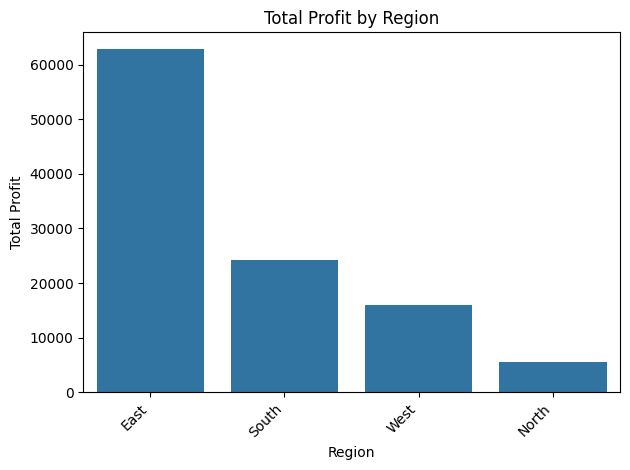

In [19]:
# Get region by profit.

df_region_profit = df_sale.join(df_customer, df_sale.customer_id == df_customer.customer_id) \
    .groupBy(df_customer.region) \
    .agg(F.sum(df_sale.sale_amount).alias("total_profit")) \
    .orderBy(F.desc("total_profit"))

df_region_profit.show()

df_region_profit_pd = df_region_profit.toPandas()

# Create the bar plot
sns.barplot(x="region", y="total_profit", data=df_region_profit_pd)
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.title("Total Profit by Region")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

+------+-----------+------------------+
|region|   category|      total_profit|
+------+-----------+------------------+
|  East|Electronics|          58400.28|
|  East|   Clothing|4083.2400000000002|
|  East|     Sports|            276.92|
| North|   Clothing|           3583.52|
| North|Electronics|1690.6200000000001|
| North|     Sports|            336.26|
| South|Electronics|20711.520000000004|
| South|   Clothing|           3387.34|
| South|     Sports|             39.56|
|  West|Electronics|          13656.52|
|  West|   Clothing|2370.7799999999997|
|  West|     Sports|             19.78|
+------+-----------+------------------+



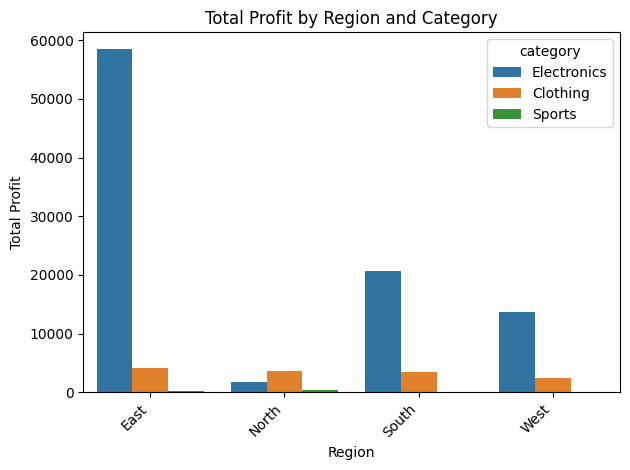

In [20]:
# Get the most profitable category for by region.

df_region_category_profit = df_sale.join(df_customer, df_sale.customer_id == df_customer.customer_id) \
    .join(df_product, df_sale.product_id == df_product.product_id) \
    .groupBy(df_customer.region, df_product.category) \
    .agg(F.sum(df_sale.sale_amount).alias("total_profit")) \
    .orderBy(df_customer.region, F.desc("total_profit"))

df_region_category_profit.show()

df_region_category_profit_pd = df_region_category_profit.toPandas()

# Create the bar plot
sns.barplot(x="region", y="total_profit", hue="category", data=df_region_category_profit_pd)
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.title("Total Profit by Region and Category")
plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels for readability
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()